# 04. Potrivirea probabilistă: Fellegi–Sunter, regresia logistică, SVM și rețeaua neuronală

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Notebook-ul 03 a pregătit, pentru fiecare rând de legat, o listă de produse candidate din Nomenclator și un vector de comparare pentru fiecare pereche. Aici aplicăm modelele care transformă vectorul de comparare într-o probabilitate de potrivire și decidem, pentru fiecare rând, ce produs din Nomenclator îi corespunde sau dacă nu îi corespunde niciunul. Comparăm două familii de modele. Modelul Fellegi–Sunter nu are nevoie de exemple etichetate și își estimează parametrii prin algoritmul EM direct din datele de legat, în variantă frecventistă și bayesiană. Regresia logistică, mașina cu vectori suport și rețeaua neuronală învață din exemplele cu răspuns cunoscut ale setului semisintetic.

Toate modelele primesc aceleași informații despre o pereche, adică asemănarea denumirii, a dozei, a formei, a numărului de unități, a volumului, a firmei și a substanței active. Ele diferă doar prin felul în care combină aceste informații. Evaluarea se face pe setul semisintetic, unde răspunsul corect este cunoscut. Pentru ca evaluarea să fie cinstită, rândurile setului sunt împărțite după marcă, astfel încât modelele supervizate să fie testate pe mărci pe care nu le-au văzut la antrenare. În final aplicăm toate modelele pe lista CNAM. Evaluarea pe cele 200 de rânduri CNAM etichetate manual și explicarea deciziilor prin SHAP și LIME urmează în notebook-ul 05. Codul se află în fișierele src/fellegi_sunter.py și src/models.py.

## 0. Pregătirea mediului

**Ce căutăm.** Încărcăm modulele și fișierele salvate de notebook-ul 03, adică perechile candidate cu vectorul de comparare pentru cele două variante ale setului semisintetic și pentru lista CNAM, rândurile setului semisintetic și Nomenclatorul cu clasele de produs. Perechile sunt ordonate după rând, pentru că modelul unu-la-unu are nevoie ca perechile aceluiași rând să fie consecutive.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib
from scipy import sparse           # matrice rare (agregarea eșantioanelor bayesiene pe rânduri)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

from compare import LEVEL_COLS                                      # nivelurile de acord (notebook 03)
from fellegi_sunter import (Levels, Rows, em, em_1to1, gibbs_1to1,  # pasul 7a: Fellegi–Sunter
                            bootstrap_1to1, params_table)
from models import (features, brand_split, fit_models, decide,      # pasul 7b: modelele supervizate
                    row_metrics, pair_metrics, bootstrap_ci, SEED)

FIG = ROOT / "reports" / "figures"
INTERIM = ROOT / "data" / "interim"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 60, "display.width", 200)

def load_pairs(name):
    # perechile ordonate după rând; nivelurile ca întregi cu valori lipsă
    p = pd.read_csv(INTERIM / f"perechi_{name}.csv").sort_values(["ia", "ib"]).reset_index(drop=True)
    for c in LEVEL_COLS:
        p[c] = p[c].astype("Int64")
    return p

n = pd.read_csv(INTERIM / "nomenclator_link.csv", dtype={"cod": str}).set_index("ib")
ro = pd.read_csv(INTERIM / "cnam_ro_link.csv", dtype=str).set_index("ia")
ro.index = ro.index.astype(int)                                       # același tip de index ca în perechi
brand_of = n.drop_duplicates("cod").set_index("cod").denumire_norm     # marca originală a fiecărui cod
S = {}
for v in ["realist", "amplificat"]:
    a = pd.read_csv(INTERIM / f"semisintetic_{v}_a.csv", dtype={"cod_adevarat": str}).set_index("ia")
    b = pd.read_csv(INTERIM / f"semisintetic_{v}_b.csv", dtype={"cod": str}).set_index("ib")
    p = load_pairs(f"semisintetic_{v}")
    a["marca"] = a.cod_adevarat.map(brand_of)
    p["marca"] = p.ia.map(a.marca)
    S[v] = {"a": a, "b": b, "p": p}
cnam = load_pairs("cnam")
for v, d in S.items():
    print(f"{v}: {len(d['a'])} rânduri, {len(d['p'])} perechi, {d['p'].potrivire.sum()} perechi corecte")
print(f"CNAM: {len(ro)} rânduri, {len(cnam)} perechi")

realist: 3653 rânduri, 74490 perechi, 3810 perechi corecte
amplificat: 3653 rânduri, 70683 perechi, 3452 perechi corecte
CNAM: 2167 rânduri, 73800 perechi


**Ce am obținut.** Setul semisintetic realist are 3.653 de rânduri și 74.490 de perechi candidate, dintre care 3.810 corecte, iar cel amplificat are tot 3.653 de rânduri, cu 70.683 de perechi, dintre care 3.452 corecte. Lista CNAM are 2.167 de rânduri și 73.800 de perechi candidate, pentru care răspunsul nu este cunoscut.

## 1. Împărțirea pe mărci

**Ce căutăm.** Același produs din Catalog apare în ambele variante ale setului semisintetic, doar cu alte variații de scriere. Dacă un model ar fi antrenat pe un produs și testat pe același produs, rezultatul ar fi prea optimist. Împărțim de aceea mărcile la întâmplare, cu seed fix, în 70% pentru antrenare și 30% pentru test. Toate rândurile și toate ambalajele unei mărci ajung în aceeași parte. Modelele supervizate se antrenează pe setul amplificat, pe mărcile de antrenare, și se testează pe mărcile de test, atât în setul realist, cât și în cel amplificat.

In [2]:
test_brands = brand_split(S["realist"]["a"].marca, test_size=0.3, seed=SEED)
for v, d in S.items():
    d["rows_test"] = d["a"].index[d["a"].marca.isin(test_brands)]
    d["test"] = d["p"][d["p"].marca.isin(test_brands)].reset_index(drop=True)
    d["true_test"] = d["test"].loc[d["test"].potrivire == 1, ["ia", "ib"]]
train = S["amplificat"]["p"][~S["amplificat"]["p"].marca.isin(test_brands)].reset_index(drop=True)

print(f"Mărci: {S['realist']['a'].marca.nunique()}, dintre care la test {len(test_brands)}")
print(f"Antrenare (amplificat, mărci de antrenare): {train.ia.nunique()} rânduri, {len(train)} perechi, "
      f"{train.potrivire.sum()} corecte")
for v, d in S.items():
    print(f"Test {v}: {len(d['rows_test'])} rânduri, {len(d['test'])} perechi, {d['test'].potrivire.sum()} corecte, "
          f"{(~d['a'].loc[d['rows_test'], 'are_pereche']).sum()} rânduri fără pereche")

Mărci: 2282, dintre care la test 685
Antrenare (amplificat, mărci de antrenare): 2486 rânduri, 47438 perechi, 2367 corecte
Test realist: 1148 rânduri, 24550 perechi, 1290 corecte, 66 rânduri fără pereche
Test amplificat: 1148 rânduri, 23245 perechi, 1085 corecte, 134 rânduri fără pereche


**Ce am obținut.** Cele 3.653 de rânduri aparțin la 2.282 de mărci, dintre care 685 au fost puse deoparte pentru test. Setul de antrenare are 2.486 de rânduri și 47.438 de perechi, dintre care 2.367 corecte. Mărcile de test cuprind 1.148 de rânduri în fiecare variantă. În setul realist ele au 24.550 de perechi, dintre care 1.290 corecte, și 66 de rânduri fără pereche, iar în cel amplificat au 23.245 de perechi, dintre care 1.085 corecte, și 134 de rânduri fără pereche.

## 2. Modelul Fellegi–Sunter clasic, estimat prin EM

**Ce căutăm.** Modelul Fellegi–Sunter presupune că fiecare pereche candidată este fie corectă, fie greșită. Pentru fiecare câmp și fiecare nivel de acord are două probabilități. Probabilitatea m este probabilitatea nivelului la o pereche corectă, iar probabilitatea u este probabilitatea lui la o pereche greșită. Raportul m/u arată cât de puternic susține nivelul respectiv potrivirea. Modelul presupune că, în interiorul fiecărei clase, câmpurile sunt independente. Algoritmul EM estimează probabilitățile fără etichete, alternând doi pași. Pasul E calculează, cu parametrii actuali, probabilitatea ca fiecare pereche să fie corectă. Pasul M recalculează parametrii ca frecvențe ponderate cu aceste probabilități. Estimăm modelul pe tot setul realist, fără să folosim etichetele, apoi comparăm valorile m estimate cu cele adevărate, pe care le cunoaștem din etichete.

In [3]:
pr = S["realist"]["p"]
L_real = Levels(pr, LEVEL_COLS)
p_cl, m_cl, u_cl, w_cl, hist_cl = em(L_real)

def true_m(p):
    # m adevărat: frecvența fiecărui nivel printre perechile corecte
    return [pd.crosstab(p[c], p.potrivire, normalize="columns").reindex(range(L_real.n_levels[c])).fillna(0).loc[l, 1]
            for c in LEVEL_COLS for l in range(L_real.n_levels[c])]

tab_cl = params_table(m_cl, u_cl).assign(**{"m adevărat": true_m(pr)})
print(f"Iterații EM: {len(hist_cl)}; proporția perechilor corecte estimată: {p_cl:.3f}, "
      f"adevărată: {pr.potrivire.mean():.3f}")
tab_cl.round(3)

Iterații EM: 39; proporția perechilor corecte estimată: 0.154, adevărată: 0.051


,câmp,nivel,m,u,pondere log2(m/u),m adevărat
0,denumire,0,0.000,0.781,-11.707,0.000
1,denumire,1,0.068,0.177,-1.371,0.003
2,denumire,2,0.064,0.036,0.821,0.020
3,denumire,3,0.868,0.006,7.130,0.977
4,doza,0,0.374,0.698,-0.899,0.000
5,doza,1,0.043,0.038,0.167,0.000
6,doza,2,0.583,0.263,1.145,0.999
7,forma,0,0.117,0.506,-2.110,0.007
8,forma,1,0.022,0.087,-1.996,0.020
9,forma,2,0.861,0.408,1.079,0.973


**Ce am obținut.** EM a ajuns la convergență după 39 de iterații, dar a estimat că 15,4% dintre perechi sunt corecte, de trei ori mai mult decât proporția adevărată de 5,1%. Probabilitățile m pentru denumire și firmă sunt apropiate de cele adevărate, de exemplu 0,965 față de 0,987 la firma foarte asemănătoare. Pentru câmpurile care descriu ambalajul, estimările sunt însă foarte departe. Doza egală are m estimat 0,583 față de 0,999, numărul de unități egal 0,617 față de 1,000, iar volumul egal 0,661 față de 0,999. Explicația este că modelul a găsit grupul perechilor cu aceeași marcă și aceeași firmă, nu grupul perechilor cu același produs. O marcă are de obicei mai multe ambalaje și doze, toate cu aceeași denumire și firmă, iar presupunerea că acordul pe denumire și acordul pe firmă sunt independente nu mai este adevărată.

**Constatare 1.** Modelul Fellegi–Sunter clasic, estimat prin EM, identifică grupul produselor din aceeași marcă în locul produsului exact, pentru că ambalajele aceleiași mărci încalcă presupunerea de independență condiționată a câmpurilor. El supraestimează de trei ori proporția perechilor corecte și subestimează cu aproximativ 0,4 probabilitățile de acord pentru doză, numărul de unități și volum.

## 3. Modelul Fellegi–Sunter cu constrângerea unu-la-unu

**Ce căutăm.** Problema modelului clasic este că tratează fiecare pereche separat, deși știm că fiecare rând are cel mult un produs corect printre candidații săi. Constrângerea unu-la-unu, propusă de Jaro în 1989 și folosită în varianta bayesiană de Sadinle în 2017, introduce această informație în model. Pentru fiecare rând, cu probabilitatea rho perechea corectă se află printre candidați, iar fiecare candidat are a priori aceeași șansă să fie el. Cu probabilitatea 1 minus rho rândul nu are pereche. Astfel candidații aceluiași rând concurează între ei, iar ambalajele unei mărci nu mai pot fi toate corecte în același timp. Am încercat înainte și modele cu trei clase, cu o clasă separată pentru aceeași marcă și alt ambalaj, dar EM a împărțit și atunci perechile după marcă, așa că le-am abandonat.

In [4]:
rows_real = Rows(pr.ia)
rho_1, m_1, u_1, w_1, hist_1 = em_1to1(L_real, rows_real)
tab_1 = params_table(m_1, u_1).assign(**{"m adevărat": true_m(pr)})
print(f"Iterații EM: {len(hist_1)}; proporția rândurilor cu pereche estimată (rho): {rho_1:.3f}, "
      f"adevărată: {S['realist']['a'].are_pereche.mean():.3f}")
print(f"Abaterea medie absolută a lui m față de valoarea adevărată: "
      f"clasic {np.abs(tab_cl.m - tab_cl['m adevărat']).mean():.3f}, unu-la-unu {np.abs(tab_1.m - tab_1['m adevărat']).mean():.3f}")
tab_1.round(3)

Iterații EM: 17; proporția rândurilor cu pereche estimată (rho): 0.951, adevărată: 0.945
Abaterea medie absolută a lui m față de valoarea adevărată: clasic 0.148, unu-la-unu 0.001


,câmp,nivel,m,u,pondere log2(m/u),m adevărat
0,denumire,0,0.000,0.693,-11.457,0.000
1,denumire,1,0.005,0.168,-4.949,0.003
2,denumire,2,0.024,0.041,-0.768,0.020
3,denumire,3,0.970,0.098,3.304,0.977
4,doza,0,0.002,0.681,-8.669,0.000
5,doza,1,0.001,0.041,-6.196,0.000
6,doza,2,0.998,0.278,1.843,0.999
7,forma,0,0.007,0.467,-6.029,0.007
8,forma,1,0.020,0.079,-1.994,0.020
9,forma,2,0.973,0.453,1.102,0.973


**Ce am obținut.** Cu constrângerea unu-la-unu, EM a ajuns la convergență după 17 iterații. Proporția estimată a rândurilor care au pereche este 0,951, foarte aproape de valoarea adevărată de 0,945. Probabilitățile m estimate coincid practic cu cele adevărate. Abaterea medie absolută scade de la 0,148 la modelul clasic la 0,001. De exemplu, doza egală are m 0,998 față de 0,999, denumirea identică 0,970 față de 0,977, iar firma foarte asemănătoare 0,987, exact valoarea adevărată.

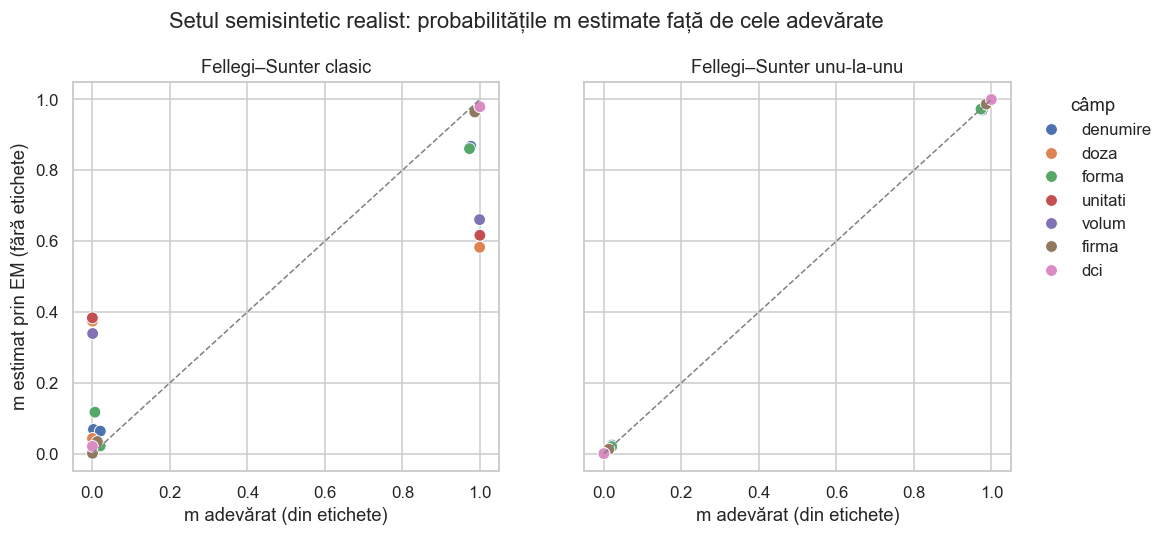

In [5]:
# Figura 11: m estimat (fără etichete) față de m adevărat, pentru modelul clasic și cel unu-la-unu
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, tab, title in zip(axes, [tab_cl, tab_1], ["Fellegi–Sunter clasic", "Fellegi–Sunter unu-la-unu"]):
    sns.scatterplot(data=tab, x="m adevărat", y="m", hue="câmp", s=60, ax=ax, legend=(ax is axes[1]))
    ax.plot([0, 1], [0, 1], color="grey", lw=1, ls="--")
    ax.set_title(title); ax.set_xlabel("m adevărat (din etichete)"); ax.set_ylabel("m estimat prin EM (fără etichete)")
axes[1].legend(title="câmp", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.suptitle("Setul semisintetic realist: probabilitățile m estimate față de cele adevărate", y=1.02)
fig.savefig(FIG / "fig11_fs_m_estimat_adevarat.png")
plt.show()

**Ce am obținut.** Figura 11 arată aceeași comparație vizual. La modelul clasic, punctele pentru doză, numărul de unități și volum stau departe de diagonală, la aproximativ 0,6 în loc de 1 și la aproximativ 0,35 în loc de 0. La modelul unu-la-unu toate punctele stau pe diagonală, deci modelul a învățat fără nicio etichetă aceleași probabilități pe care le calculăm din etichete.

**Constatare 2.** Introducerea constrângerii unu-la-unu, adică a faptului că fiecare rând are cel mult un produs corect printre candidați, rezolvă problema modelului clasic. Fără să folosească etichete, EM regăsește proporția rândurilor cu pereche, 0,951 față de 0,945, și probabilitățile m ale tuturor câmpurilor, cu o abatere medie de 0,001 față de valorile adevărate.

## 4. Incertitudinea: frecventist și bayesian

**Ce căutăm.** EM dă o singură valoare pentru fiecare parametru. Ca să știm cât de sigură este această valoare, folosim două abordări. Abordarea frecventistă este bootstrap-ul. Reluăm EM pe 50 de eșantioane de rânduri extrase cu revenire, iar intervalul de încredere de 95% este dat de percentilele 2,5 și 97,5 ale valorilor obținute. Abordarea bayesiană tratează parametrii ca variabile aleatoare. Pornim de la distribuții a priori neinformative, Beta pentru rho și Dirichlet pentru probabilitățile m și u, iar eșantionarea Gibbs produce distribuția lor a posteriori. Gibbs repetă trei pași. Alege pentru fiecare rând care candidat este perechea sau dacă nu are pereche, actualizează rho și apoi actualizează m și u. Facem 1.500 de iterații, renunțăm la primele 500 ca perioadă de încălzire și păstrăm fiecare a cincea, adică 200 de eșantioane. Comparăm cele două intervale pe setul realist, unde cunoaștem valorile adevărate, și pe lista CNAM.

In [6]:
def interval_table(L, rows, pairs, label):
    boot_tab, boot_rho = bootstrap_1to1(pairs, LEVEL_COLS, n_boot=50, seed=SEED)
    g = gibbs_1to1(L, rows, seed=SEED, init=em_1to1(L, rows)[:3])
    out = [{"set": label, "parametru": "rho (rânduri cu pereche)", "metodă": "bootstrap (frecventist)",
            "inf": np.percentile(boot_rho, 2.5), "sup": np.percentile(boot_rho, 97.5)},
           {"set": label, "parametru": "rho (rânduri cu pereche)", "metodă": "Gibbs (bayesian)",
            "inf": np.percentile(g["rho"], 2.5), "sup": np.percentile(g["rho"], 97.5)}]
    for c, lvl in [("niv_denumire", 3), ("niv_doza", 2), ("niv_forma", 2), ("niv_firma", 2)]:
        bt = boot_tab[(boot_tab.camp == c) & (boot_tab.nivel == lvl)].m
        name = f"m {c.replace('niv_', '')} = nivelul {lvl}"
        out.append({"set": label, "parametru": name, "metodă": "bootstrap (frecventist)",
                    "inf": np.percentile(bt, 2.5), "sup": np.percentile(bt, 97.5)})
        out.append({"set": label, "parametru": name, "metodă": "Gibbs (bayesian)",
                    "inf": np.percentile(g["m"][c][:, lvl], 2.5), "sup": np.percentile(g["m"][c][:, lvl], 97.5)})
    return pd.DataFrame(out), g

iv_real, g_real = interval_table(L_real, rows_real, pr, "semisintetic realist")
L_cnam, rows_cnam = Levels(cnam, LEVEL_COLS), Rows(cnam.ia)
iv_cnam, g_cnam = interval_table(L_cnam, rows_cnam, cnam, "CNAM")
truth = {"rho (rânduri cu pereche)": S["realist"]["a"].are_pereche.mean()}
truth.update({f"m {c.replace('niv_', '')} = nivelul {l}": tab_1.loc[(tab_1["câmp"] == c.replace("niv_", "")) & (tab_1.nivel == l), "m adevărat"].iloc[0]
              for c, l in [("niv_denumire", 3), ("niv_doza", 2), ("niv_forma", 2), ("niv_firma", 2)]})
iv = pd.concat([iv_real, iv_cnam])
iv["valoarea adevărată"] = np.where(iv.set == "semisintetic realist", iv.parametru.map(truth), np.nan)
iv["conține valoarea adevărată"] = np.where(iv.set == "semisintetic realist",
                                           (iv.inf <= iv["valoarea adevărată"]) & (iv["valoarea adevărată"] <= iv.sup), None)
iv.round(4)

,set,parametru,metodă,inf,sup,valoarea adevărată,conține valoarea adevărată
0,semisintetic realist,rho (rânduri cu pereche),bootstrap (frecventist),0.9434,0.9588,0.9447,True
1,semisintetic realist,rho (rânduri cu pereche),Gibbs (bayesian),0.9420,0.9576,0.9447,True
2,semisintetic realist,m denumire = nivelul 3,bootstrap (frecventist),0.9662,0.9756,0.9766,False
3,semisintetic realist,m denumire = nivelul 3,Gibbs (bayesian),0.9635,0.9755,0.9766,False
4,semisintetic realist,m doza = nivelul 2,bootstrap (frecventist),0.9959,0.9990,0.9994,False
5,semisintetic realist,m doza = nivelul 2,Gibbs (bayesian),0.9947,0.9992,0.9994,False
6,semisintetic realist,m forma = nivelul 2,bootstrap (frecventist),0.9679,0.9771,0.9732,True
7,semisintetic realist,m forma = nivelul 2,Gibbs (bayesian),0.9681,0.9784,0.9732,True
8,semisintetic realist,m firma = nivelul 2,bootstrap (frecventist),0.9833,0.9902,0.9869,True
9,semisintetic realist,m firma = nivelul 2,Gibbs (bayesian),0.9824,0.9904,0.9869,True


**Ce am obținut.** Pe setul realist, intervalul pentru proporția rândurilor cu pereche este de la 0,943 la 0,959 prin bootstrap și de la 0,942 la 0,958 prin Gibbs, iar valoarea adevărată de 0,945 se află în ambele. Intervalele pentru formă și firmă conțin și ele valoarea adevărată. Pentru denumire și doză valoarea adevărată se află chiar deasupra intervalului, la mai puțin de 0,002 de capătul lui. Intervalele măsoară doar variația datorată eșantionului, nu și micile abateri ale modelului de la realitate, de aceea pot rata valoarea adevărată cu foarte puțin. Pe lista CNAM, proporția rândurilor care au pereche în Nomenclator este estimată între 0,947 și 0,967 prin bootstrap și între 0,945 și 0,965 prin Gibbs. Probabilitatea de acord pe firmă este mai mică în CNAM, între 0,925 și 0,950, față de aproximativ 0,99 în setul semisintetic, ceea ce confirmă că firmele diferă mai des în lista reală, cum am văzut în notebook-ul 03.

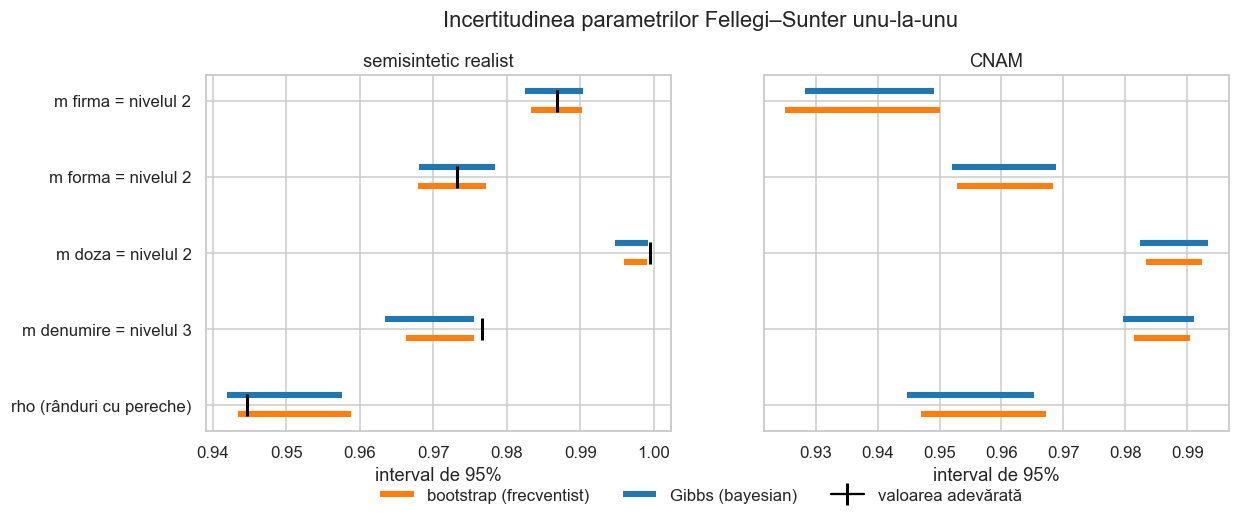

In [7]:
# Figura 12: intervalele de 95% pentru rho și m, bootstrap față de Gibbs
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, (label, d) in zip(axes, iv.groupby("set", sort=False)):
    params = d.parametru.unique()
    for i, prm in enumerate(params):
        for j, (met, col) in enumerate([("bootstrap (frecventist)", "#ff7f0e"), ("Gibbs (bayesian)", "#1f77b4")]):
            r = d[(d.parametru == prm) & (d["metodă"] == met)].iloc[0]
            ax.plot([r.inf, r.sup], [i + (j - 0.5) * 0.25] * 2, color=col, lw=4, solid_capstyle="butt",
                    label=met if i == 0 else None)
        if label == "semisintetic realist":
            ax.plot(truth[prm], i, marker="|", color="black", ms=14, mew=2, label="valoarea adevărată" if i == 0 else None)
    ax.set_yticks(range(len(params))); ax.set_yticklabels(params)
    ax.set_title(label); ax.set_xlabel("interval de 95%")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08), frameon=False)
fig.suptitle("Incertitudinea parametrilor Fellegi–Sunter unu-la-unu", y=1.02)
fig.savefig(FIG / "fig12_incertitudine_fs.png")
plt.show()

**Ce am obținut.** Figura 12 arată că cele două abordări dau intervale aproape identice, atât pe setul semisintetic, cât și pe lista CNAM. Era de așteptat, deoarece avem multe date, iar distribuțiile a priori sunt neinformative, iar în această situație rezultatul bayesian și cel frecventist se apropie. Avantajul variantei bayesiene apare la nivelul fiecărui rând, unde ea dă direct un interval pentru probabilitatea de potrivire, cum se vede în secțiunea 7.

**Constatare 3.** Bootstrap-ul și eșantionarea Gibbs dau intervale de incertitudine aproape identice pentru parametrii modelului unu-la-unu. Pe setul realist intervalele au o lățime de aproximativ 0,016 pentru proporția rândurilor cu pereche și conțin valoarea adevărată. Pe lista CNAM, proporția rândurilor care au pereche în Nomenclator este estimată între 94,5% și 96,7%.

## 5. Modelele supervizate

**Ce căutăm.** Antrenăm trei modele pe perechile setului amplificat care aparțin mărcilor de antrenare. Regresia logistică dă fiecărui scor de asemănare o pondere și le adună, iar rezultatul este transformat în probabilitate printr-o funcție sigmoidă. Este modelul de referință, simplu și ușor de interpretat. Mașina cu vectori suport, pe scurt SVM, caută granița care desparte perechile corecte de cele greșite cu cea mai mare margine. Cu nucleul RBF granița poate fi curbă. SVM nu dă direct probabilități, așa că îl calibrăm prin metoda Platt, care potrivește o regresie logistică pe scorul lui. Rețeaua neuronală are două straturi ascunse, de 32 și 16 neuroni, și poate învăța combinații de câmpuri. Pentru fiecare model alegem un hiperparametru prin validare încrucișată în trei părți, cu mărcile separate între părți. Criteriul de alegere este aria sub curba precizie–recall.

In [8]:
fitted, chosen = fit_models(features(train), train.potrivire, train.marca)
for name, prm in chosen.items():
    sc = list(prm["scoruri CV"].values())
    # diferența dintre cel mai bun și cel mai slab scor din grilă (scorurile SVM variază la a patra zecimală între rulări)
    print(f"{name}: {[f'{k} = {v}' for k, v in prm.items() if k != 'scoruri CV'][0]}; "
          f"diferența dintre scorurile valorilor încercate: {max(sc) - min(sc):.2f}")

regresie logistică: logisticregression__C = 0.1; diferența dintre scorurile valorilor încercate: 0.00
SVM (RBF): svc__C = 1.0; diferența dintre scorurile valorilor încercate: 0.00
rețea neuronală: mlpclassifier__alpha = 0.001; diferența dintre scorurile valorilor încercate: 0.00


**Ce am obținut.** Validarea încrucișată a ales valoarea C egală cu 0,1 pentru regresia logistică, valoarea C egală cu 1 pentru SVM și valoarea alpha de 0,001 pentru rețeaua neuronală. Scorurile valorilor încercate diferă între ele cu mai puțin de 0,005 din aria sub curba precizie–recall, deci rezultatele nu depind mult de această alegere. Când scorurile sunt aproape egale, adică la mai puțin de 0,001 unul de altul, regula noastră alege modelul cel mai simplu, cu regularizarea cea mai puternică. Fără această regulă, zgomotul numeric al SVM-ului schimba alegerea de la o rulare la alta, iar rezultatele nu erau perfect reproductibile.

## 6. Comparația modelelor pe mărcile de test

**Ce căutăm.** Aplicăm toate modelele pe mărcile de test și le comparăm în două feluri. Pe perechi măsurăm aria sub curba precizie–recall, care arată cât de bine ordonează modelul perechile corecte înaintea celor greșite, și scorul Brier, adică eroarea pătratică medie a probabilităților, care arată cât de bine sunt calibrate. Pe rânduri măsurăm decizia finală. Pentru fiecare rând alegem clasa de produs cu probabilitatea cea mai mare și o acceptăm dacă probabilitatea ei este de cel puțin 0,5. Precizia arată ce parte din legăturile făcute sunt corecte, iar recall-ul arată ce parte din rândurile care au pereche au fost legate corect. Modelele Fellegi–Sunter sunt estimate direct pe rândurile de test, fără etichete, exact cum vor fi aplicate pe lista CNAM. Pentru F1 calculăm și un interval de încredere de 95% prin bootstrap pe rânduri.

In [9]:
def all_models(d, b_classes):
    # probabilitățile tuturor modelelor pe perechile de test și decizia pe rânduri
    te, out, probs = d["test"], {}, {}
    for name, mdl in fitted.items():
        probs[name] = (mdl.predict_proba(features(te))[:, 1], False)
    L = Levels(te, LEVEL_COLS)
    probs["Fellegi–Sunter clasic"] = (em(L)[3], False)
    probs["Fellegi–Sunter unu-la-unu"] = (em_1to1(L, Rows(te.ia))[3], True)
    for name, (pr_, excl) in probs.items():
        best = decide(te, pr_, b_classes, exclusive=excl)
        lo, hi = bootstrap_ci(best, d["true_test"], d["rows_test"], n_boot=500, seed=SEED)
        out[name] = {**pair_metrics(te.potrivire, pr_), **row_metrics(best, d["true_test"], d["rows_test"]),
                     "F1 IC95% inf": lo, "F1 IC95% sup": hi}
    return pd.DataFrame(out).T, probs

comp, probs_test = {}, {}
for v, d in S.items():
    comp[v], probs_test[v] = all_models(d, d["b"].clasa_produs)
# trei zecimale: SVM-ul (libsvm) are un zgomot numeric la a patra zecimală între rulări
print("Mărcile de test, setul realist:")
print(comp["realist"].round(3).to_string())
print("\nMărcile de test, setul amplificat:")
print(comp["amplificat"].round(3).to_string())

Mărcile de test, setul realist:
                           AP (perechi)  Brier (perechi)  precizie  recall     F1  acuratețe pe rânduri  rânduri legate greșit  rânduri cu pereche nelegate  F1 IC95% inf  F1 IC95% sup
regresie logistică                0.996            0.003     0.994   0.998  0.996                 0.993                    7.0                          2.0         0.993         0.998
SVM (RBF)                         0.996            0.002     0.998   0.995  0.997                 0.995                    2.0                          5.0         0.994         0.999
rețea neuronală                   0.994            0.003     0.996   0.989  0.993                 0.987                    4.0                         12.0         0.989         0.996
Fellegi–Sunter clasic             0.960            0.091     0.991   0.998  0.994                 0.991                   10.0                          2.0         0.990         0.998
Fellegi–Sunter unu-la-unu         0.997         

**Ce am obținut.** Pe mărcile de test din setul realist, toate modelele au rezultate foarte bune, cu F1 pe rânduri între 0,993 și 0,997. SVM-ul și modelul Fellegi–Sunter unu-la-unu au cel mai mare F1, 0,997, regresia logistică are 0,996, modelul clasic 0,995, iar rețeaua neuronală 0,993. Intervalele de încredere se suprapun în mare parte, deci diferențele sunt mici. Pe perechi, modelul unu-la-unu ordonează cel mai bine perechile, cu o arie sub curba precizie–recall de 0,997, iar SVM-ul are cele mai bine calibrate probabilități, cu un scor Brier de 0,002. Modelul clasic are o arie de doar 0,960 și un scor Brier de 0,091, de peste zece ori mai mare decât al celorlalte modele. Pe setul amplificat diferențele devin vizibile. Modelul unu-la-unu are cel mai mare F1, 0,977, cu intervalul de la 0,969 la 0,983, față de 0,955 până la 0,966 la modelele supervizate. Intervalul lui nu se suprapune cu cel al rețelei neuronale. Modelele supervizate au o precizie ușor mai mare, între 0,980 și 0,986, dar lasă nelegate între 49 și 73 de rânduri care au pereche, față de 31 la modelul unu-la-unu. Modelul clasic leagă greșit 51 de rânduri, de peste trei ori mai multe decât celelalte modele.

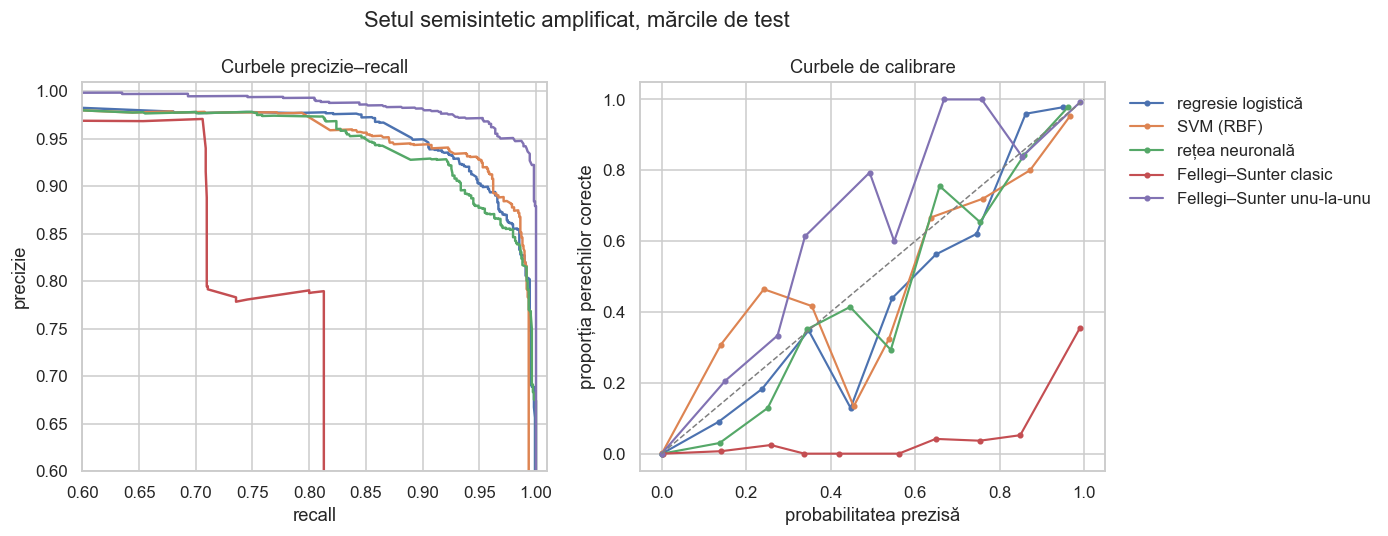

In [10]:
# Figura 13: curbele precizie–recall (pe perechi) și curbele de calibrare (10 intervale egale de probabilitate),
# setul amplificat, mărcile de test
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
te = S["amplificat"]["test"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for name, (pr_, _) in probs_test["amplificat"].items():
    prec, rec, _ = precision_recall_curve(te.potrivire, pr_)
    axes[0].plot(rec, prec, label=name, lw=1.6)
    frac, mean_pred = calibration_curve(te.potrivire, pr_, n_bins=10, strategy="uniform")
    axes[1].plot(mean_pred, frac, marker="o", ms=3, label=name, lw=1.4)
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precizie"); axes[0].set_xlim(0.6, 1.01); axes[0].set_ylim(0.6, 1.01)
axes[0].set_title("Curbele precizie–recall")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
axes[1].set_xlabel("probabilitatea prezisă"); axes[1].set_ylabel("proporția perechilor corecte")
axes[1].set_title("Curbele de calibrare")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.suptitle("Setul semisintetic amplificat, mărcile de test", y=1.02)
fig.savefig(FIG / "fig13_precizie_recall_calibrare.png")
plt.show()

**Ce am obținut.** În figura 13, curba precizie–recall a modelului unu-la-unu stă deasupra celorlalte pe aproape tot intervalul. Curba modelului clasic coboară brusc pe la un recall de 0,7, când încep să fie acceptate celelalte ambalaje ale aceleiași mărci. Curbele de calibrare sunt neregulate între 0,2 și 0,8, pentru că acolo se află puține perechi, majoritatea având probabilități foarte apropiate de 0 sau de 1. Modelele supervizate urmează în mare diagonala. Modelul unu-la-unu stă mai degrabă deasupra ei, deci este prudent, iar perechile cărora le dă o probabilitate medie sunt corecte mai des decât spune probabilitatea. Modelul clasic stă mult sub diagonală. Dintre perechile cărora le dă o probabilitate în jur de 0,85, doar aproximativ 5% sunt corecte, deci probabilitățile lui sunt mult prea mari.

**Constatare 4.** Modelul Fellegi–Sunter cu constrângerea unu-la-unu, estimat fără etichete, obține pe setul realist același F1 pe rânduri ca cel mai bun model supervizat, 0,997. Pe setul amplificat îi depășește pe toți, cu F1 de 0,977 față de 0,955 până la 0,966. Modelele supervizate dau probabilități ceva mai bine calibrate pe setul realist. Modelul clasic are un F1 comparabil, dar probabilitățile lui sunt puternic supraestimate.

## 7. Aplicarea pe lista CNAM

**Ce căutăm.** Aplicăm acum toate modelele pe perechile candidate ale listei CNAM. Modelele supervizate folosesc ce au învățat pe setul semisintetic. Modelele Fellegi–Sunter se estimează direct pe perechile CNAM, fără etichete. Pentru fiecare model și fiecare rând CNAM obținem produsul ales din Nomenclator și probabilitatea lui. Măsurăm câte rânduri leagă fiecare model, cât de des sunt de acord modelele între ele și dacă rândurile potrivite exact în notebook-ul 02 primesc produsul cu aceeași denumire, doză și formă.

In [11]:
probs_cnam = {name: (mdl.predict_proba(features(cnam))[:, 1], False) for name, mdl in fitted.items()}
probs_cnam["Fellegi–Sunter clasic"] = (em(L_cnam)[3], False)
probs_cnam["Fellegi–Sunter unu-la-unu"] = (em_1to1(L_cnam, rows_cnam)[3], True)
probs_cnam["Fellegi–Sunter bayesian"] = (g_cnam["w"].mean(1), True)       # media a posteriori

dec = {name: decide(cnam, pr_, n.clasa_produs, exclusive=excl) for name, (pr_, excl) in probs_cnam.items()}
all_rows = ro.index

# potrivirea exactă din notebook-ul 02 (denumire, doză, formă normalizate), ca reper
exact_keys = set(zip(n.denumire_norm, n.doza_norm, n.forma_norm))
exact = pd.Series([k in exact_keys for k in zip(ro.denumire_norm, ro.doza_norm, ro.forma_norm)], index=all_rows)
key_n = pd.Series(list(zip(n.denumire_norm, n.doza_norm, n.forma_norm)), index=n.index)
key_r = pd.Series(list(zip(ro.denumire_norm, ro.doza_norm, ro.forma_norm)), index=all_rows)

summary = {}
for name, best in dec.items():
    b_ = best.reindex(all_rows)
    linked = b_.legat.fillna(False).astype(bool)
    same_key = pd.Series([key_n.get(ib) == key_r[ia] if pd.notna(ib) else False for ia, ib in zip(b_.index, b_.ib)], index=all_rows)
    summary[name] = {"rânduri legate": int(linked.sum()), "% legate": linked.mean() * 100,
                     "rânduri potrivite exact în nb. 02, legate la aceeași cheie (%)": (linked & same_key)[exact].mean() * 100,
                     "rânduri nepotrivite exact în nb. 02, legate (%)": linked[~exact].mean() * 100}
print(f"Rânduri CNAM: {len(all_rows)}; potrivite exact în notebook-ul 02: {exact.sum()}")
pd.DataFrame(summary).T.round(1)

Rânduri CNAM: 2167; potrivite exact în notebook-ul 02: 1972


,rânduri legate,% legate,"rânduri potrivite exact în nb. 02, legate la aceeași cheie (%)","rânduri nepotrivite exact în nb. 02, legate (%)"
regresie logistică,2023.0,93.4,97.9,46.7
SVM (RBF),2016.0,93.0,97.5,47.7
rețea neuronală,2015.0,93.0,97.3,48.2
Fellegi–Sunter clasic,2089.0,96.4,99.9,60.0
Fellegi–Sunter unu-la-unu,2073.0,95.7,99.2,57.9
Fellegi–Sunter bayesian,2073.0,95.7,99.2,57.9


**Ce am obținut.** Modelele supervizate leagă între 2.015 și 2.023 de rânduri CNAM, adică aproximativ 93%. Modelul unu-la-unu și varianta lui bayesiană leagă 2.073 de rânduri, adică 95,7%, iar modelul clasic 2.089, adică 96,4%. Proporția modelului unu-la-unu coincide cu estimarea lui rho din secțiunea 4. Dintre cele 1.972 de rânduri potrivite exact în notebook-ul 02, modelul unu-la-unu leagă 99,2% de un produs cu aceeași denumire, doză și formă, iar modelele supervizate între 97,3% și 97,9%. Diferența principală apare la cele 195 de rânduri pe care potrivirea exactă nu le-a putut lega. Modelele supervizate leagă între 47% și 48% dintre ele, iar modelul unu-la-unu 58%. Care dintre proporții este mai aproape de adevăr vom afla în notebook-ul 05, din rândurile etichetate manual.

**Ce căutăm.** Verificăm cât de des aleg modelele același produs. Pentru fiecare pereche de modele calculăm proporția rândurilor CNAM pentru care ambele iau aceeași decizie, adică același produs sau amândouă fără pereche.

In [12]:
def choice(best):
    b_ = best.reindex(all_rows)
    return pd.Series(np.where(b_.legat.fillna(False).astype(bool), n.clasa_produs.reindex(b_.ib).to_numpy(), -1), index=all_rows)

ch = pd.DataFrame({name: choice(best) for name, best in dec.items()})
agree = pd.DataFrame({a: {b: (ch[a] == ch[b]).mean() * 100 for b in ch} for a in ch})
print(f"Rânduri pentru care toate cele {ch.shape[1]} modele iau aceeași decizie: {(ch.nunique(axis=1) == 1).mean():.1%}")
agree.round(1)

Rânduri pentru care toate cele 6 modele iau aceeași decizie: 91.2%


,regresie logistică,SVM (RBF),rețea neuronală,Fellegi–Sunter clasic,Fellegi–Sunter unu-la-unu,Fellegi–Sunter bayesian
regresie logistică,100.0,99.0,99.3,92.7,97.0,97.0
SVM (RBF),99.0,100.0,98.3,92.2,96.2,96.2
rețea neuronală,99.3,98.3,100.0,92.2,96.4,96.4
Fellegi–Sunter clasic,92.7,92.2,92.2,100.0,94.8,94.8
Fellegi–Sunter unu-la-unu,97.0,96.2,96.4,94.8,100.0,100.0
Fellegi–Sunter bayesian,97.0,96.2,96.4,94.8,100.0,100.0


**Ce am obținut.** Toate cele șase modele iau aceeași decizie pentru 91,2% dintre rândurile CNAM. Modelele supervizate sunt de acord între ele în 98,3% până la 99,3% din rânduri, iar cu modelul unu-la-unu în 96,2% până la 97,0%. Modelul clasic se deosebește cel mai mult de celelalte. Varianta bayesiană ia exact aceleași decizii ca varianta EM a modelului unu-la-unu, ceea ce era de așteptat, pentru că parametrii lor sunt practic egali.

**Ce căutăm.** Varianta bayesiană dă pentru fiecare rând nu doar o probabilitate, ci o distribuție a ei, din cele 200 de eșantioane Gibbs. Calculăm pentru produsul ales intervalul credibil de 95% al probabilității și numărăm rândurile la care intervalul trece de o parte și de alta a pragului de 0,5. Pentru aceste rânduri decizia este nesigură și ar trebui verificată de un om.

In [13]:
best_b = dec["Fellegi–Sunter bayesian"]
cls = n.clasa_produs.reindex(cnam.ib).to_numpy()
chosen_cls = best_b.clasa.reindex(cnam.ia).to_numpy()
# matricea rânduri × perechi care adună probabilitățile codurilor din clasa aleasă a fiecărui rând
sel = np.flatnonzero(cls == chosen_cls)
row_pos = pd.Index(best_b.index).get_indexer(cnam.ia.to_numpy()[sel])
M = sparse.csr_matrix((np.ones(len(sel)), (row_pos, sel)), shape=(len(best_b), len(cnam)))
samples = np.asarray(M @ g_cnam["w"])                                     # rânduri × eșantioane
best_b["inf95"], best_b["sup95"] = np.percentile(samples, 2.5, axis=1), np.percentile(samples, 97.5, axis=1)
unsure = best_b[(best_b.inf95 < 0.5) & (best_b.sup95 >= 0.5)]
print(f"Rânduri cu candidați: {len(best_b)}; legate: {best_b.legat.sum()}; "
      f"cu interval credibil care traversează pragul 0,5: {len(unsure)}")
print(f"Lățimea mediană a intervalului: {(best_b.sup95 - best_b.inf95).median():.4f}; "
      f"rânduri cu lățimea peste 0,1: {((best_b.sup95 - best_b.inf95) > 0.1).sum()}")
show = unsure.join(ro[["denumire", "doza", "forma", "divizare"]]).join(n[["denumire", "doza", "forma", "divizare"]], on="ib", rsuffix=" (Nomenclator)")
show[["denumire", "doza", "forma", "divizare", "denumire (Nomenclator)", "doza (Nomenclator)", "forma (Nomenclator)",
      "divizare (Nomenclator)", "prob", "inf95", "sup95"]].round(3).head(12)

Rânduri cu candidați: 2165; legate: 2073; cu interval credibil care traversează pragul 0,5: 27
Lățimea mediană a intervalului: 0.0057; rânduri cu lățimea peste 0,1: 127


,denumire,doza,forma,divizare,denumire (Nomenclator),doza (Nomenclator),forma (Nomenclator),divizare (Nomenclator),prob,inf95,sup95
ia,,,,,,,,,,,
13,Sanocard,150 mg,comprimate gastrorezistente,N10x3,Sanocard,150 mg,comprimate gastrorezistente,N10x3,0.590,0.450,0.702
14,Protecardin,75 mg,comp. gastrorez.,N20x2,PROTECARDIN®,75 mg,comprimate gastrorezistente,N20x2,0.584,0.440,0.699
16,Sanocard,75 mg,comprimate gastrorezistente,N10x3,Sanocard,75 mg,comprimate gastrorezistente,N10x3,0.589,0.449,0.699
17,ASK,75 mg,comprimate gastrorezistente,N10x3,ASK,75 mg,comprimate gastrorezistente,N10x3,0.591,0.451,0.704
539,Mixtard® 30 HM,100 UI/ml - 10 ml,suspensie injectabilă,N1,Protaphane® HM,100 UI/ml,suspensie injectabilă,N1,0.722,0.375,0.895
540,Mixtard® 30 HM Penfill®,100 UI/ml - 3 ml,"suspensie injectabilă, cartuș",N5,Actrapid® HM Penfill®,100 UI/ml,soluţie injectabilă în cartuş,N5,0.489,0.222,0.776
734,Clorură de sodiu 45 mg/5 ml,9 mg/ml - 5 ml,soluţie injectabilă,N5,Clorură de sodiu 9 mg/ml,9 mg/ml,soluţie injectabilă,N5,0.744,0.317,0.908
1029,Tamoxifen,20 mg,comprimate,N15x2,Tamoximed,20 mg,comprimate,N15x2,0.576,0.367,0.752
1073,Travopic,40 mcg/ml,"picături oftalmice, soluţie",N1,Glautan,"0,04 mg/ml","picături oftalmice, soluţie",N1,0.612,0.241,0.828


**Ce am obținut.** Dintre cele 2.165 de rânduri CNAM care au candidați, 2.073 sunt legate. Intervalul credibil de 95% al probabilității are o lățime mediană de numai 0,006, deci pentru majoritatea rândurilor decizia este sigură. Pentru 127 de rânduri intervalul este mai lat de 0,1, iar pentru 27 de rânduri el traversează pragul de 0,5. Exemplele arată de ce aceste rânduri sunt nesigure. La Sanocard, ASK și Protecardin toate câmpurile coincid, cu excepția firmei, pe care lista CNAM o scrie Acino Ucraina, iar Nomenclatorul Balkan Pharmaceuticals. Pentru Mixtard 30 HM cel mai apropiat candidat este altă insulină, Protaphane sau Actrapid. Tamoxifen de la Balkan Pharmaceuticals poate corespunde fie mărcii Tamoximed a aceleiași firme, fie produsului Tamoxifen al altei firme, iar Travopic este apropiat de Glautan, o marcă diferită cu aceeași substanță. Acestea sunt exact cazurile pe care un om ar trebui să le verifice.

**Constatare 5.** Aplicate pe lista CNAM, modelele leagă între 93,0% și 96,4% dintre rânduri de un produs din Nomenclator, iar toate cele șase modele iau aceeași decizie pentru 91,2% dintre rânduri. Varianta bayesiană a modelului unu-la-unu semnalează 27 de rânduri cu decizie nesigură, adică cu intervalul credibil al probabilității de o parte și de alta a pragului de 0,5. Acestea sunt în principal cazuri cu firmă diferită sau cu mărci înrudite, care merită verificate manual.

## 8. Rezumat și pașii următori

Am comparat două familii de modele de potrivire. Modelul Fellegi–Sunter clasic, estimat prin EM fără etichete, a confundat produsul exact cu marca, pentru că ambalajele aceleiași mărci încalcă presupunerea lui de independență. Adăugarea constrângerii unu-la-unu a rezolvat această problemă. Modelul a regăsit fără etichete probabilitățile adevărate ale setului semisintetic și a obținut pe setul realist rezultate la fel de bune ca cel mai bun model supervizat, iar pe setul amplificat rezultate mai bune decât regresia logistică, SVM-ul și rețeaua neuronală. Varianta bayesiană, estimată prin eșantionare Gibbs, dă aceleași decizii și aceleași intervale ca bootstrap-ul pentru parametri. Pe deasupra, ea oferă pentru fiecare rând un interval al probabilității, care semnalează cele 27 de rânduri CNAM cu decizie nesigură.

În notebook-ul 05 vom evalua toate modelele pe cele 200 de rânduri CNAM etichetate manual. Metricile vor fi reponderate după straturi și însoțite de intervale de încredere bootstrap, vom verifica calibrarea și vom face analiza de sensibilitate fără cele 91 de etichete pre-completate. Tot acolo vom explica deciziile modelelor prin SHAP și, pe câteva exemple, prin LIME și vom alege modelul folosit pentru integrarea listei CNAM cu prețurile.

**Ce căutăm.** Salvăm decizia fiecărui model pentru fiecare rând CNAM, cu codul ales, probabilitatea și, la varianta bayesiană, intervalul credibil, pentru evaluarea finală pe rândurile etichetate manual din notebook-ul 05.

In [14]:
out = pd.DataFrame(index=all_rows)
out.index.name = "id_cnam"
for name, best in dec.items():
    b_ = best.reindex(all_rows)
    key = (name.replace("Fellegi–Sunter", "fs").replace("regresie logistică", "lr").replace("SVM (RBF)", "svm")
               .replace("rețea neuronală", "mlp").replace(" ", "_").replace("-", "_"))
    out[f"{key}_cod"] = np.where(b_.legat.fillna(False).astype(bool), n.cod.reindex(b_.ib).to_numpy(), None)
    out[f"{key}_prob"] = b_.prob.to_numpy()
out["fs_bayesian_inf95"] = best_b.inf95.reindex(all_rows).to_numpy()
out["fs_bayesian_sup95"] = best_b.sup95.reindex(all_rows).to_numpy()
out.to_csv(INTERIM / "potriviri_cnam.csv")
cnam.assign(**{f"prob_{k}": v for k, (v, _) in probs_cnam.items()}).to_csv(INTERIM / "perechi_cnam_probabilitati.csv", index=False)
print(out.shape, list(out.columns))

(2167, 14) ['lr_cod', 'lr_prob', 'svm_cod', 'svm_prob', 'mlp_cod', 'mlp_prob', 'fs_clasic_cod', 'fs_clasic_prob', 'fs_unu_la_unu_cod', 'fs_unu_la_unu_prob', 'fs_bayesian_cod', 'fs_bayesian_prob', 'fs_bayesian_inf95', 'fs_bayesian_sup95']


**Ce am obținut.** Fișierul potriviri_cnam.csv are câte un rând pentru fiecare dintre cele 2.167 de rânduri CNAM și 14 coloane, adică codul ales și probabilitatea lui pentru fiecare dintre cele șase modele, plus intervalul credibil al variantei bayesiene. Fișierul perechi_cnam_probabilitati.csv păstrează probabilitatea fiecărui model pentru fiecare pereche candidată, pentru explicațiile din notebook-ul 05.